# Problem Statement
The dataset contains information about customers who purchase clothing from an e-commerce store. Customers receive in-store styling sessions and then place orders either through the company’s website or mobile app. The company wants to determine whether to focus more on improving its mobile app or its website.

# Objective
In this project, we aim to predict the yearly amount spent by a customer based on several features such as time spent on the app, time spent on the website, length of membership, and average session length.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Ecommerce Customers')

To understand the structure of the dataset, we first examine the data using methods like head(), info(), and describe().

In [18]:
display(df.head())
display(df.info())
display(df.describe())

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


None

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


We'll analyze the relationship between platform usage and customer spending, joint plots were created for Time on Website and Time on App against Yearly Amount Spent.

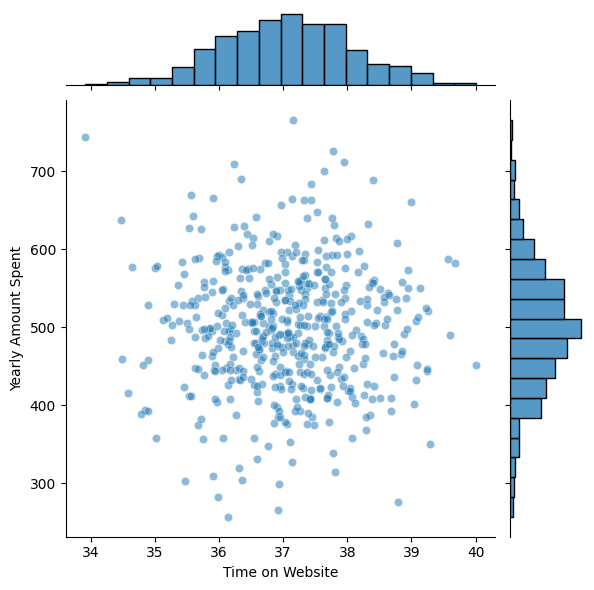

In [19]:
sns.jointplot(x = 'Time on Website', y = 'Yearly Amount Spent', data = df, alpha = 0.5)

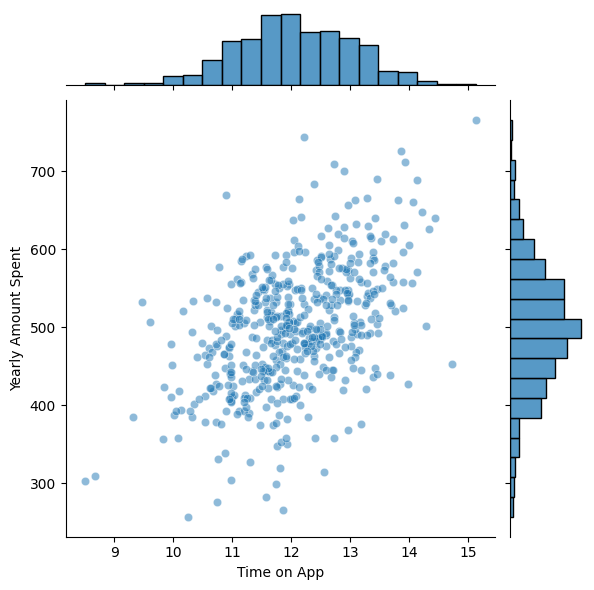

In [20]:
sns.jointplot(x = 'Time on App', y = 'Yearly Amount Spent', data = df, alpha = 0.5)

From these visualizations, it appears that Time on App has a stronger positive relationship with customer spending compared to Time on Website.

To further explore the relationships between all numerical features, a pairplot is used to visualize the interactions between variables.

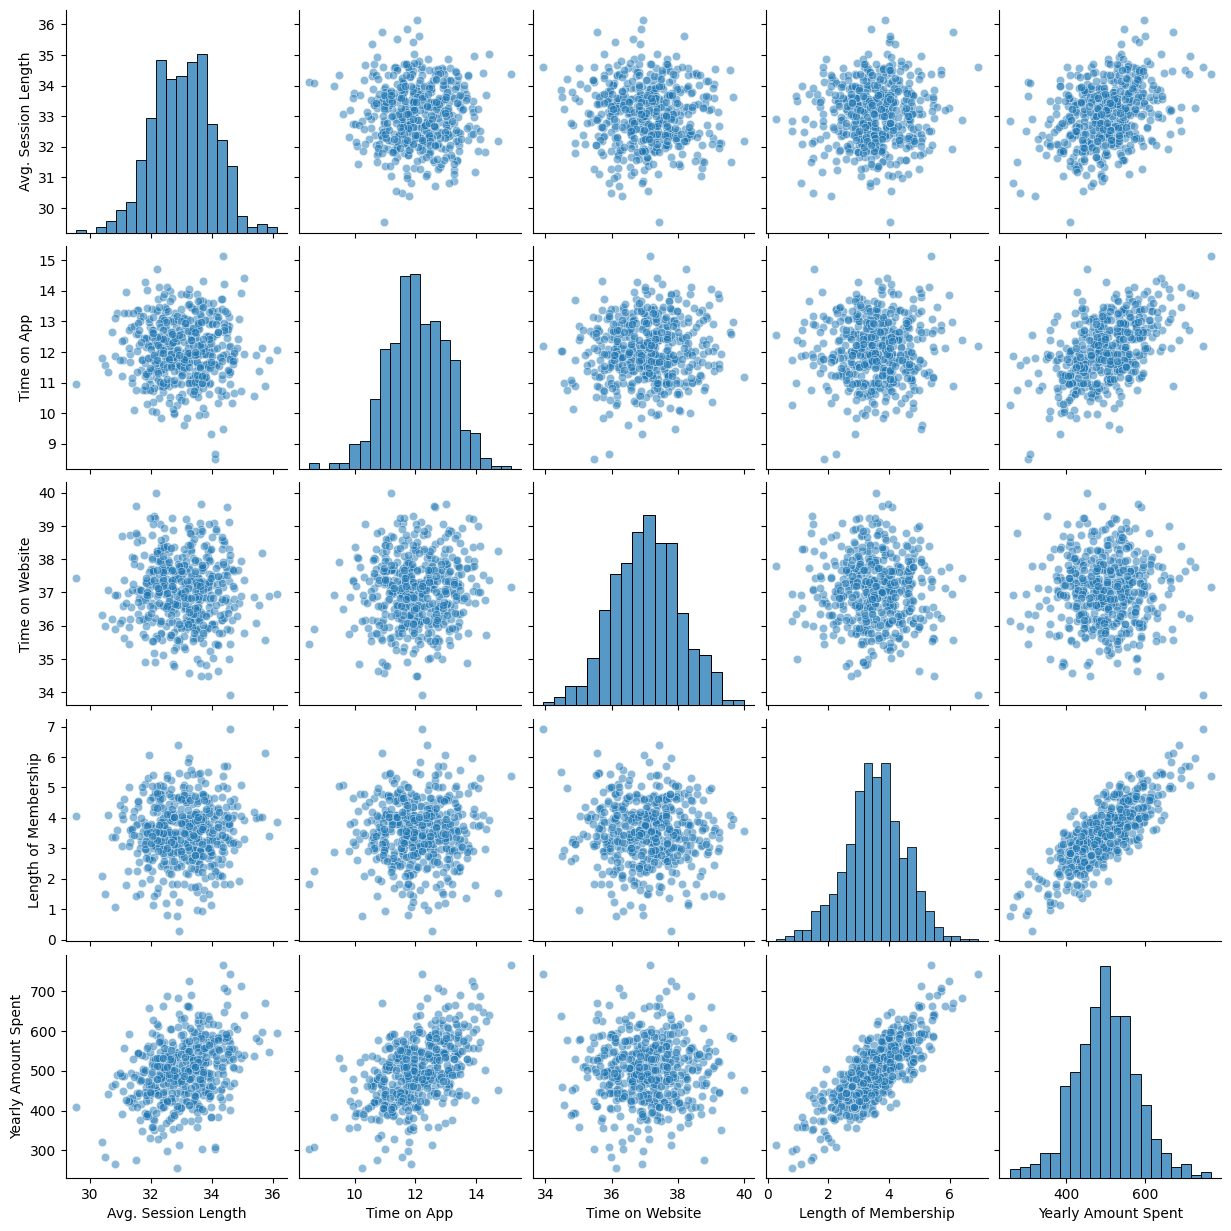

In [21]:
sns.pairplot(df, kind = 'scatter', plot_kws = {'alpha': 0.5})

From the pairplot, it is evident that Length of Membership has a strong and nearly linear relationship with Yearly Amount Spent, indicating that customers who have been members for longer tend to spend more.

To further examine the relationship between Length of Membership and Yearly Amount Spent, a linear regression plot is used to visualize the trend.

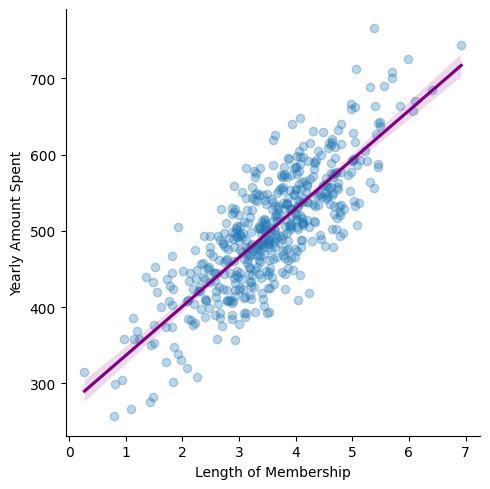

In [22]:
sns.lmplot(x = 'Length of Membership', 
           y = 'Yearly Amount Spent', data = df,
           scatter_kws = {'alpha': 0.3},
           line_kws = {'color': 'purple'})

The plot shows a strong linear relationship between Length of Membership and Yearly Amount Spent, indicating that customers who have been members for a longer duration tend to spend more annually.

## Model Training

Based on the insights gained from exploratory data analysis, a linear regression model is built to quantify the relationship between customer features and yearly spending, and to make future predictions.

In [23]:
from sklearn.model_selection import train_test_split

X = df[['Avg. Session Length', 'Time on App', 'Time on Website',	'Length of Membership']]
y = df['Yearly Amount Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

##  Training the Model

In [24]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Interpretation

To understand the impact of each feature on the target variable, the coefficients of the trained linear regression model are examined.

In [25]:
lm.coef_
cdf = pd.DataFrame(lm.coef_, X.columns,  columns = ['Coef'])
cdf

,Coef
Avg. Session Length,25.724256
Time on App,38.597135
Time on Website,0.459148
Length of Membership,61.674732


From the coefficients, it can be observed that *Length of Membership* has the highest impact on yearly spending. Among the platform-related features, *Time on App* has a stronger influence compared to *Time on Website*.

### Model Predictions
The trained model is used to make predictions on the test dataset to evaluate its performance.

In [26]:
predictions = lm.predict(X_test)

To visualize the model’s performance, a scatter plot is created comparing the actual values with the predicted values.

Text(0.5, 1.0, 'Final Evaluation of the LR model')

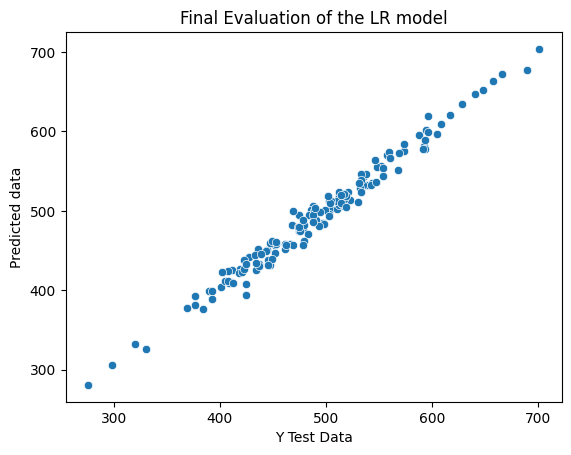

In [27]:
sns.scatterplot(x = y_test, y = predictions)
plt.xlabel('Y Test Data')
plt.ylabel('Predicted data')
plt.title('Final Evaluation of the LR model')

From the plot, it can be observed that the predicted values closely follow the actual values, forming a near-linear pattern. This indicates that the model performs well and is able to make accurate predictions.

### Evaluation Metrics

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [29]:
print("mean_absolute_error: ", mean_absolute_error(y_test, predictions))
print("mean_squared_error: ", mean_squared_error(y_test, predictions))
print("root_mean_squared_error: ", math.sqrt(mean_squared_error(y_test, predictions)))

mean_absolute_error:  8.426091641432116
mean_squared_error:  103.91554136503333
root_mean_squared_error:  10.193897260863155


The Mean Absolute Error (MAE) is approximately 8.42, indicating that on average, the model’s predictions deviate from the actual values by around 8 units. 

The Root Mean Squared Error (RMSE) is approximately 10.19, which also suggests that the model has a relatively low prediction error.

Overall, these metrics indicate that the model performs well and provides accurate predictions.

## Residual Analysis

To further evaluate the model, the residuals (difference between actual and predicted values) are analyzed to check whether they follow a normal distribution.

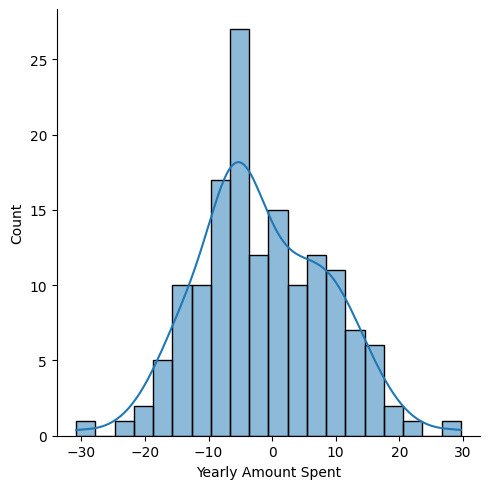

In [30]:
residuals = y_test - predictions

sns.displot(residuals, bins = 20, kde = True)

From the distribution of residuals, it can be observed that they are approximately normally distributed around zero. This indicates that the model’s errors are random and that the assumptions of linear regression are reasonably satisfied.

To further verify the normality of residuals, a Q-Q plot is used to compare the distribution of residuals with a theoretical normal distribution.

((array([-2.60376328, -2.283875  , -2.1005573 , -1.96875864, -1.86428437,
         -1.77691182, -1.70131573, -1.63435332, -1.57400778, -1.51890417,
         -1.46806125, -1.42075308, -1.37642684, -1.33465133, -1.29508341,
         -1.25744533, -1.22150891, -1.18708433, -1.15401181, -1.12215558,
         -1.0913992 , -1.06164202, -1.03279638, -1.00478546, -0.97754152,
         -0.95100448, -0.92512081, -0.89984257, -0.87512664, -0.85093408,
         -0.8272296 , -0.80398107, -0.78115919, -0.75873709, -0.73669013,
         -0.71499557, -0.69363244, -0.67258128, -0.65182406, -0.63134396,
         -0.61112532, -0.59115349, -0.57141472, -0.55189613, -0.53258558,
         -0.51347162, -0.49454346, -0.47579085, -0.45720409, -0.43877397,
         -0.4204917 , -0.40234892, -0.38433762, -0.36645016, -0.3486792 ,
         -0.33101768, -0.31345882, -0.29599609, -0.27862316, -0.26133393,
         -0.24412247, -0.22698303, -0.20991002, -0.19289797, -0.17594158,
         -0.15903562, -0.142175  , -0.

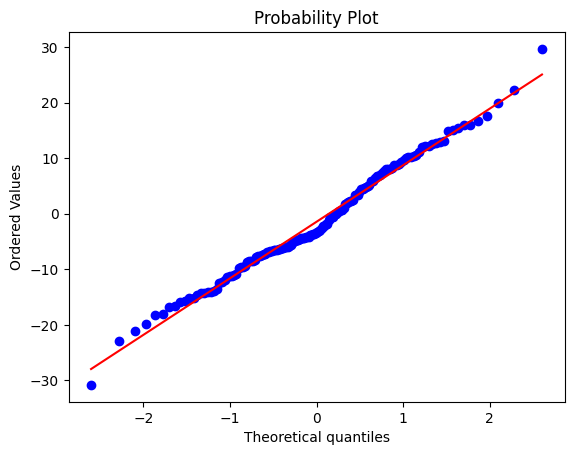

In [31]:
import matplotlib.pyplot as plt
import scipy.stats as stats

stats.probplot(residuals, dist = 'norm', plot = plt)

From the Q-Q plot, it can be observed that the residuals lie approximately along a straight line. This indicates that the residuals follow a normal distribution, and the assumptions of linear regression are satisfied.

# Conclusion

From the analysis, it is evident that *Length of Membership* has the strongest influence on the yearly amount spent by customers. This suggests that long-term customer relationships play a crucial role in increasing revenue.

Among the platform-related features, *Time on App* shows a stronger relationship with customer spending compared to *Time on Website*. Therefore, the company should consider focusing more on improving the mobile app experience.

Additionally, the linear regression model performs well, as indicated by both visual and quantitative evaluations, and is able to make accurate predictions of customer spending.